# ❄️ Snowstorm Flight Delay Predictor
## Notebook 2: Feature Engineering + Model Training

**What we'll do:**
1. Load our clean Newark winter dataset
2. Engineer powerful features (this is where ML gets impressive)
3. Train 3 models: Logistic Regression, Random Forest, XGBoost
4. Compare them with Accuracy, Precision, Recall, ROC-AUC
5. Save the best model for Day 3's dashboard

In [1]:
# ----- STEP 1: Import Libraries -----

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ML libraries
from sklearn.model_selection import train_test_split    # Split data into train/test
from sklearn.preprocessing import StandardScaler        # Normalize numbers
from sklearn.linear_model import LogisticRegression     # Model 1: Simple baseline
from sklearn.ensemble import RandomForestClassifier     # Model 2: Decision tree ensemble
from xgboost import XGBClassifier                       # Model 3: Gradient boosting (best likely)

# Evaluation tools
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve)

# For saving the model
import joblib

plt.style.use('seaborn-v0_8-whitegrid')
print('✅ All libraries loaded!')

ModuleNotFoundError: No module named 'pandas'

In [ ]:
# ----- STEP 2: Load Clean Dataset from Day 1 -----

df = pd.read_csv('../data/ewr_winter_clean.csv')
print(f'📊 Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'   Delayed: {df["DELAYED"].sum():,} ({df["DELAYED"].mean()*100:.1f}%)')
print(f'   On-time: {(df["DELAYED"]==0).sum():,} ({(1-df["DELAYED"].mean())*100:.1f}%)')
df.head()

📊 Loaded: 31,121 rows × 27 columns
   Delayed: 8,090 (26.0%)
   On-time: 23,031 (74.0%)


,MONTH,DAY_OF_WEEK,DEP_DEL15,DEP_TIME_BLK,DISTANCE_GROUP,SEGMENT_NUMBER,CONCURRENT_FLIGHTS,NUMBER_OF_SEATS,CARRIER_NAME,AIRPORT_FLIGHTS_MONTH,...,DEPARTING_AIRPORT,LATITUDE,LONGITUDE,PREVIOUS_AIRPORT,PRCP,SNOW,SNWD,TMAX,AWND,DELAYED
0,1,5,0,0800-0859,5,1,31,110,Delta Air Lines Inc.,10281,...,Newark Liberty International,40.696,-74.172,NONE,0.0,0.0,0.0,33.0,14.99,0
1,1,5,0,0800-0859,3,1,31,110,Delta Air Lines Inc.,10281,...,Newark Liberty International,40.696,-74.172,NONE,0.0,0.0,0.0,33.0,14.99,0
2,1,5,0,0600-0659,3,1,21,149,Delta Air Lines Inc.,10281,...,Newark Liberty International,40.696,-74.172,NONE,0.0,0.0,0.0,33.0,14.99,0
3,1,5,0,0700-0759,3,1,28,149,Delta Air Lines Inc.,10281,...,Newark Liberty International,40.696,-74.172,NONE,0.0,0.0,0.0,33.0,14.99,0
4,1,5,1,2000-2059,3,1,26,129,Atlantic Southeast Airlines,10281,...,Newark Liberty International,40.696,-74.172,NONE,0.0,0.0,0.0,33.0,14.99,1


In [ ]:
df = pd.read_csv('../data/ewr_winter_clean.csv')
print(f"Total flights: {df.shape[0]:,}")
print(f"Flights with snow > 0: {(df['SNOW'] > 0).sum():,}")
print(f"Max snowfall: {df['SNOW'].max():.1f} inches")
print(f"\nSnow distribution:")
print(df['SNOW'].describe())

Total flights: 31,121
Flights with snow > 0: 4,146
Max snowfall: 2.7 inches

Snow distribution:
count    31121.000000
mean         0.103226
std          0.403582
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          2.700000
Name: SNOW, dtype: float64


## 🧠 Step 3: Feature Engineering
This is where your model goes from basic to impressive.  
Instead of just feeding raw data, we **create new features** that capture real-world patterns.

In [ ]:
# ---- FEATURE ENGINEERING ----
# We'll create new columns that help the model understand the data better

# 1. ❄️ Heavy snow flag (more than 1 inch)
df['HEAVY_SNOW'] = (df['SNOW'] > 1).astype(int)
print(f'❄️ Heavy snow flights: {df["HEAVY_SNOW"].sum():,}')

# 2. 🌡️ Below freezing flag (TMAX < 32°F means it stayed cold all day)
df['BELOW_FREEZING'] = (df['TMAX'] < 32).astype(int)
print(f'🌡️ Below freezing flights: {df["BELOW_FREEZING"].sum():,}')

# 3. 🌬️ High wind flag (wind > 15 mph — causes operational issues)
df['HIGH_WIND'] = (df['AWND'] > 15).astype(int)
print(f'🌬️ High wind flights: {df["HIGH_WIND"].sum():,}')

# 4. 🌧️ Any precipitation flag
df['HAS_PRECIP'] = (df['PRCP'] > 0).astype(int)
print(f'🌧️ Precipitation flights: {df["HAS_PRECIP"].sum():,}')

# 5. 📏 Snow on ground flag (existing snow depth makes things worse)
df['SNOW_ON_GROUND'] = (df['SNWD'] > 0).astype(int)
print(f'📏 Snow on ground flights: {df["SNOW_ON_GROUND"].sum():,}')

# 6. 🕒 Peak hour flag (rush hours = more congestion = more delays)
#    DEP_TIME_BLK has blocks like '0700-0759', '1700-1759'
#    Morning rush: 7-9 AM, Evening rush: 4-7 PM
peak_blocks = ['0700-0759', '0800-0859', '0900-0959', 
               '1600-1659', '1700-1759', '1800-1859', '1900-1959']
df['PEAK_HOUR'] = df['DEP_TIME_BLK'].isin(peak_blocks).astype(int)
print(f'🕒 Peak hour flights: {df["PEAK_HOUR"].sum():,}')

# NOTE: CARRIER_DELAY_RATE is computed after train/test split (Step 4b)
# to avoid data leakage (test flights' own outcomes influencing the feature)

# 7. 🌪️ Severe weather combo (snow + cold + wind = bad day)
df['SEVERE_WEATHER'] = ((df['SNOW'] > 0) & (df['TMAX'] < 35) & (df['AWND'] > 10)).astype(int)
print(f'🌪️ Severe weather flights: {df["SEVERE_WEATHER"].sum():,}')

# 8. 📅 Weekend flag
df['IS_WEEKEND'] = (df['DAY_OF_WEEK'].isin([6, 7])).astype(int)
print(f'📅 Weekend flights: {df["IS_WEEKEND"].sum():,}')

print('\n✅ All features engineered!')

In [ ]:
# Let's see the delay rate for each new feature — do they matter?

print('📊 Feature Impact on Delays:')
print('=' * 55)
binary_features = ['HEAVY_SNOW', 'BELOW_FREEZING', 'HIGH_WIND', 'HAS_PRECIP',
                   'SNOW_ON_GROUND', 'PEAK_HOUR', 'SEVERE_WEATHER', 'IS_WEEKEND']

for feat in binary_features:
    rate_yes = df[df[feat] == 1]['DELAYED'].mean() * 100
    rate_no  = df[df[feat] == 0]['DELAYED'].mean() * 100
    diff = rate_yes - rate_no
    arrow = '🔴' if diff > 5 else ('🟡' if diff > 2 else '⚪')
    print(f'  {arrow} {feat:20s} | Yes: {rate_yes:5.1f}% | No: {rate_no:5.1f}% | Diff: {diff:+.1f}%')

📊 Feature Impact on Delays:
  🔴 HEAVY_SNOW           | Yes:  46.0% | No:  25.4% | Diff: +20.6%
  🔴 BELOW_FREEZING       | Yes:  31.7% | No:  25.7% | Diff: +6.1%
  🔴 HIGH_WIND            | Yes:  34.3% | No:  24.5% | Diff: +9.8%
  🔴 HAS_PRECIP           | Yes:  32.1% | No:  22.1% | Diff: +9.9%
  🔴 SNOW_ON_GROUND       | Yes:  39.2% | No:  25.3% | Diff: +13.9%
  ⚪ PEAK_HOUR            | Yes:  26.5% | No:  25.5% | Diff: +1.0%
  ⚪ SEVERE_WEATHER       | Yes:  27.9% | No:  26.0% | Diff: +1.9%
  ⚪ IS_WEEKEND           | Yes:  22.7% | No:  27.1% | Diff: -4.5%


## 🔧 Step 4: Prepare Data for ML
Select features, split into train/test, and scale.

In [ ]:
# ----- SELECT FEATURES -----
# These are the columns the model will use to make predictions

feature_columns = [
    # Raw weather data
    'SNOW', 'SNWD', 'TMAX', 'AWND', 'PRCP',
    
    # Engineered features (the impressive part!)
    'HEAVY_SNOW', 'BELOW_FREEZING', 'HIGH_WIND', 'HAS_PRECIP',
    'SNOW_ON_GROUND', 'PEAK_HOUR', 'SEVERE_WEATHER', 'IS_WEEKEND',
    'CARRIER_DELAY_RATE',
    
    # Existing useful columns
    'MONTH', 'DAY_OF_WEEK', 'DISTANCE_GROUP', 'PLANE_AGE',
    'CONCURRENT_FLIGHTS', 'NUMBER_OF_SEATS',
    'AIRPORT_FLIGHTS_MONTH', 'AIRLINE_AIRPORT_FLIGHTS_MONTH',
]

# CARRIER_DELAY_RATE placeholder — filled properly in Step 4b after split
df['CARRIER_DELAY_RATE'] = 0.0

X = df[feature_columns].copy()
y = df['DELAYED'].copy()

# Fill any missing values with column medians (safer than 0 for non-binary features)
missing = X.isna().sum()
if missing.any():
    print('⚠️ Filling missing values with column medians:')
    print(missing[missing > 0])
    X = X.fillna(X.median())

print(f'✅ Feature matrix: {X.shape[0]:,} samples × {X.shape[1]} features')
print(f'   Target: {y.sum():,} delayed, {(y==0).sum():,} on-time')

In [ ]:
# ----- SPLIT INTO TRAIN AND TEST -----
# 80% for training, 20% for testing
# The model NEVER sees the test data during training — that's how we know it works on new data

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,       # 20% for testing
    random_state=42,     # Makes results reproducible (same split every time)
    stratify=y           # Keeps the same delayed/on-time ratio in both sets
)

print(f'📊 Train set: {X_train.shape[0]:,} samples ({y_train.mean()*100:.1f}% delayed)')
print(f'📊 Test set:  {X_test.shape[0]:,} samples ({y_test.mean()*100:.1f}% delayed)')

📊 Train set: 24,896 samples (26.0% delayed)
📊 Test set:  6,225 samples (26.0% delayed)


In [ ]:
# ----- STEP 4b: Compute CARRIER_DELAY_RATE from training data only -----
# Why: computing it from ALL data before the split lets test flights' own
# outcomes influence the feature — that's data leakage and inflates metrics.

carrier_delay_rate = (
    df.loc[X_train.index, 'CARRIER_NAME']
    .to_frame()
    .join(y_train)
    .groupby('CARRIER_NAME')['DELAYED']
    .mean()
)

X_train['CARRIER_DELAY_RATE'] = df.loc[X_train.index, 'CARRIER_NAME'].map(carrier_delay_rate)
X_test['CARRIER_DELAY_RATE'] = (
    df.loc[X_test.index, 'CARRIER_NAME']
    .map(carrier_delay_rate)
    .fillna(carrier_delay_rate.mean())  # unknown carriers get the average
)

print(f'✅ CARRIER_DELAY_RATE computed from training data only (no leakage)')
print(f'   Rate range: {carrier_delay_rate.min():.3f} – {carrier_delay_rate.max():.3f}')
print(f'   Mean rate:  {carrier_delay_rate.mean():.3f}')

In [ ]:
# ----- SCALE THE FEATURES -----
# Some columns have big numbers (AIRPORT_FLIGHTS_MONTH: ~13000)
# Others are tiny (SNOW: 0-5)
# Scaling makes them all comparable — important for Logistic Regression

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Learn scaling from training data
X_test_scaled = scaler.transform(X_test)         # Apply same scaling to test data

print('✅ Features scaled!')
print(f'   Example — before scaling: mean={X_train["AIRPORT_FLIGHTS_MONTH"].mean():.0f}')
print(f'   Example — after scaling:  mean={X_train_scaled[:, feature_columns.index("AIRPORT_FLIGHTS_MONTH")].mean():.4f}')

✅ Features scaled!
   Example — before scaling: mean=10425
   Example — after scaling:  mean=-0.0000


## 🤖 Step 5: Train 3 Models
We'll compare:
1. **Logistic Regression** — simple baseline (like a straight line)
2. **Random Forest** — many decision trees voting together
3. **XGBoost** — state-of-the-art gradient boosting (wins most competitions)

In [ ]:
# ----- MODEL 1: LOGISTIC REGRESSION (Baseline) -----
# Think of this as drawing a line between delayed and on-time flights

print('🏋️ Training Model 1: Logistic Regression...')
lr_model = LogisticRegression(
    class_weight='balanced',  # Handles imbalanced data (more on-time than delayed)
    max_iter=1000,            # Give it enough iterations to converge
    random_state=42
)
lr_model.fit(X_train_scaled, y_train)  # Uses scaled data
lr_preds = lr_model.predict(X_test_scaled)
lr_probs = lr_model.predict_proba(X_test_scaled)[:, 1]  # Probability of delay
print('✅ Logistic Regression done!')

🏋️ Training Model 1: Logistic Regression...
✅ Logistic Regression done!


In [ ]:
# ----- MODEL 2: RANDOM FOREST -----
# Imagine 200 decision trees all voting on whether a flight will be delayed

print('🏋️ Training Model 2: Random Forest...')
rf_model = RandomForestClassifier(
    n_estimators=200,         # 200 trees in the forest
    max_depth=15,             # Don't let trees get too deep (prevents overfitting)
    class_weight='balanced',  # Handle imbalanced data
    random_state=42,
    n_jobs=-1                 # Use all CPU cores for speed
)
rf_model.fit(X_train, y_train)  # Random Forest doesn't need scaling
rf_preds = rf_model.predict(X_test)
rf_probs = rf_model.predict_proba(X_test)[:, 1]
print('✅ Random Forest done!')

🏋️ Training Model 2: Random Forest...
✅ Random Forest done!


In [ ]:
# ----- MODEL 3: XGBOOST -----
# The most powerful model — learns from its mistakes iteratively

print('🏋️ Training Model 3: XGBoost...')

# Calculate scale_pos_weight for imbalanced data
# This tells XGBoost to pay more attention to the minority class (delayed)
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = XGBClassifier(
    n_estimators=200,          # 200 boosting rounds
    max_depth=6,               # Moderate tree depth
    learning_rate=0.1,         # How fast it learns (slower = more careful)
    scale_pos_weight=scale_pos,# Handle imbalanced data
    random_state=42,
    eval_metric='logloss',     # What it optimizes for
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)  # XGBoost doesn't need scaling either
xgb_preds = xgb_model.predict(X_test)
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]
print('✅ XGBoost done!')

🏋️ Training Model 3: XGBoost...
✅ XGBoost done!


## 📊 Step 6: Evaluate & Compare Models

In [ ]:
# ----- MODEL COMPARISON TABLE -----
# This is your key deliverable for Day 2!

def evaluate_model(name, y_true, y_pred, y_prob):
    """Calculate all metrics for a model."""
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1 Score': f1_score(y_true, y_pred),
        'ROC-AUC': roc_auc_score(y_true, y_prob)
    }

results = pd.DataFrame([
    evaluate_model('Logistic Regression', y_test, lr_preds, lr_probs),
    evaluate_model('Random Forest', y_test, rf_preds, rf_probs),
    evaluate_model('XGBoost', y_test, xgb_preds, xgb_probs),
])

# Format as percentages
print('\n🏆 MODEL COMPARISON TABLE')
print('=' * 75)
display_results = results.copy()
for col in ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']:
    display_results[col] = display_results[col].apply(lambda x: f'{x:.3f}')
print(display_results.to_string(index=False))
print('=' * 75)

# Which model won?
best_idx = results['ROC-AUC'].idxmax()
best_model_name = results.loc[best_idx, 'Model']
best_auc = results.loc[best_idx, 'ROC-AUC']
print(f'\n🥇 Best model by ROC-AUC: {best_model_name} ({best_auc:.3f})')


🏆 MODEL COMPARISON TABLE
              Model Accuracy Precision Recall F1 Score ROC-AUC
Logistic Regression    0.624     0.366  0.611    0.458   0.664
      Random Forest    0.732     0.481  0.417    0.447   0.711
            XGBoost    0.702     0.448  0.629    0.523   0.732

🥇 Best model by ROC-AUC: XGBoost (0.732)


In [ ]:
# ----- WHAT DO THESE METRICS MEAN? -----
# (Beginner-friendly explanation)

print('📖 Quick Guide to Metrics:')
print('-' * 60)
print('Accuracy  = What % of ALL predictions were correct?')
print('Precision = When we predict "delayed", how often are we right?')
print('Recall    = Of all ACTUAL delays, how many did we catch?')
print('F1 Score  = Balance between Precision and Recall')
print('ROC-AUC   = Overall model quality (0.5 = random, 1.0 = perfect)')
print('-' * 60)
print('\nFor our use case (predicting delays for travelers):')
print('  → HIGH RECALL is important (catch as many delays as possible)')
print('  → ROC-AUC is the best overall metric to compare models')

📖 Quick Guide to Metrics:
------------------------------------------------------------
Accuracy  = What % of ALL predictions were correct?
Precision = When we predict "delayed", how often are we right?
Recall    = Of all ACTUAL delays, how many did we catch?
F1 Score  = Balance between Precision and Recall
ROC-AUC   = Overall model quality (0.5 = random, 1.0 = perfect)
------------------------------------------------------------

For our use case (predicting delays for travelers):
  → HIGH RECALL is important (catch as many delays as possible)
  → ROC-AUC is the best overall metric to compare models


## 📈 Step 7: Visualization — ROC Curves

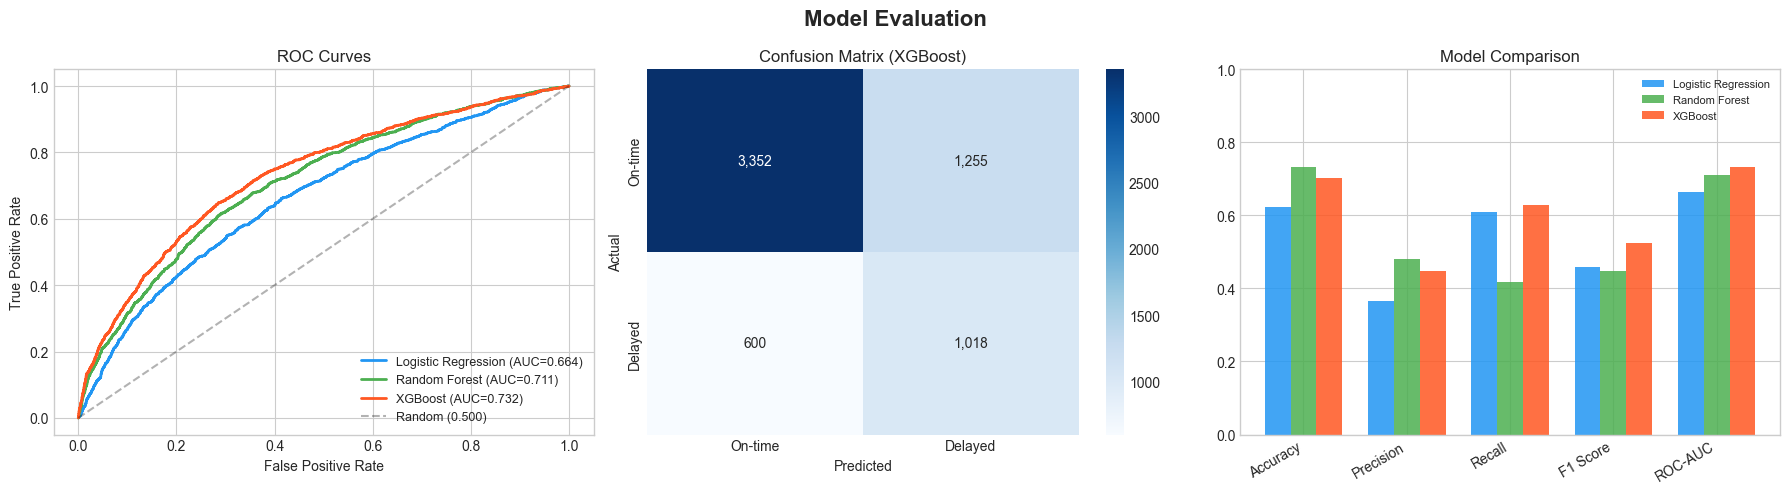

✅ Chart saved to data/model_comparison.png


In [ ]:
# ----- ROC CURVES -----
# This shows each model's tradeoff between catching delays vs false alarms

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Model Evaluation', fontsize=16, fontweight='bold')

# Plot 1: ROC Curves (all 3 models)
ax = axes[0]
for name, probs, color in [('Logistic Regression', lr_probs, '#2196F3'),
                            ('Random Forest', rf_probs, '#4CAF50'),
                            ('XGBoost', xgb_probs, '#FF5722')]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=color, linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Random (0.500)')  # Diagonal = random guessing
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves')
ax.legend(loc='lower right', fontsize=9)

# Plot 2: Confusion Matrix for best model
ax = axes[1]
# Use the best model's predictions
if best_model_name == 'XGBoost':
    best_preds = xgb_preds
elif best_model_name == 'Random Forest':
    best_preds = rf_preds
else:
    best_preds = lr_preds

cm = confusion_matrix(y_test, best_preds)
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', ax=ax,
            xticklabels=['On-time', 'Delayed'],
            yticklabels=['On-time', 'Delayed'])
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix ({best_model_name})')

# Plot 3: Model Comparison Bar Chart
ax = axes[2]
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
x = np.arange(len(metrics_to_plot))
width = 0.25

for i, (idx, row) in enumerate(results.iterrows()):
    values = [row[m] for m in metrics_to_plot]
    colors = ['#2196F3', '#4CAF50', '#FF5722']
    ax.bar(x + i*width, values, width, label=row['Model'], color=colors[i], alpha=0.85)

ax.set_xticks(x + width)
ax.set_xticklabels(metrics_to_plot, rotation=30, ha='right')
ax.set_ylim(0, 1)
ax.set_title('Model Comparison')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('../data/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart saved to data/model_comparison.png')

## 🌟 Step 8: Feature Importance
Which features matter most? This is what interviewers LOVE to see.

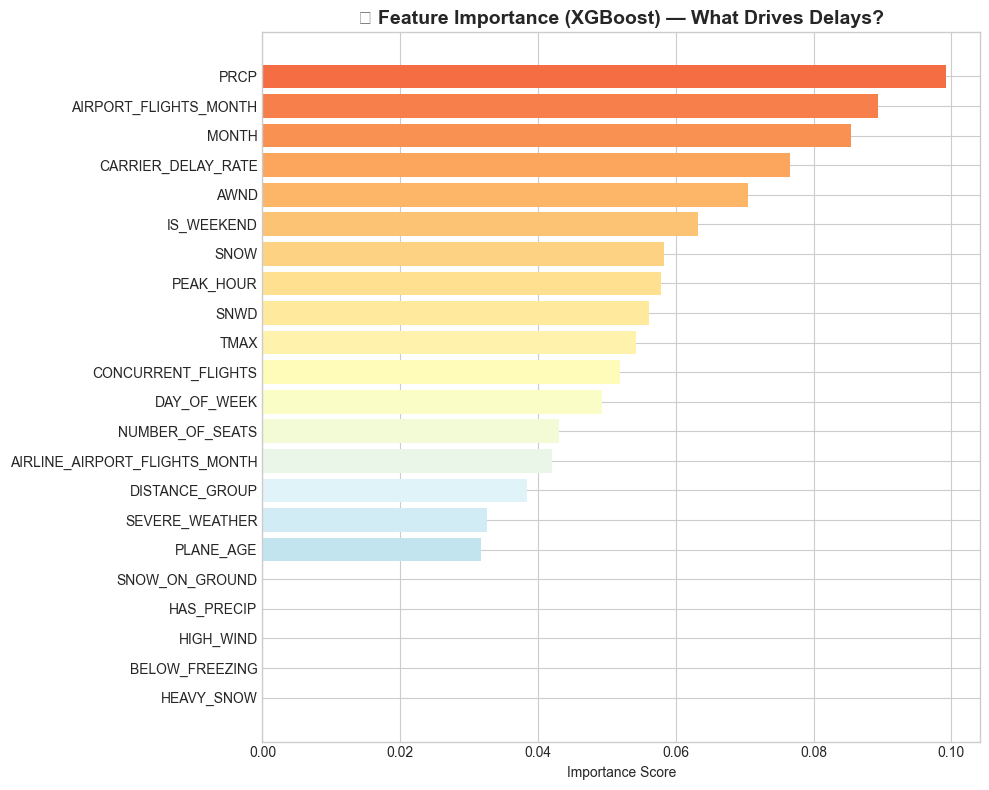


🏆 Top 5 Most Important Features:
   1. PRCP                           (0.0992)
   2. AIRPORT_FLIGHTS_MONTH          (0.0894)
   3. MONTH                          (0.0855)
   4. CARRIER_DELAY_RATE             (0.0766)
   5. AWND                           (0.0705)


In [ ]:
# ----- FEATURE IMPORTANCE (from XGBoost) -----

importance = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
colors = plt.cm.RdYlBu_r(np.linspace(0.2, 0.8, len(importance)))
ax.barh(importance['Feature'], importance['Importance'], color=colors)
ax.set_xlabel('Importance Score')
ax.set_title('🌟 Feature Importance (XGBoost) — What Drives Delays?', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Print top 5
print('\n🏆 Top 5 Most Important Features:')
for i, (_, row) in enumerate(importance.tail(5).iloc[::-1].iterrows(), 1):
    print(f'   {i}. {row["Feature"]:30s} ({row["Importance"]:.4f})')

## 📊 Step 9: Detailed Classification Report

In [ ]:
# Full classification report for the best model

print(f'\n📊 Detailed Report: {best_model_name}')
print('=' * 55)
print(classification_report(y_test, best_preds, target_names=['On-time', 'Delayed']))


📊 Detailed Report: XGBoost
              precision    recall  f1-score   support

     On-time       0.85      0.73      0.78      4607
     Delayed       0.45      0.63      0.52      1618

    accuracy                           0.70      6225
   macro avg       0.65      0.68      0.65      6225
weighted avg       0.74      0.70      0.72      6225



## 💾 Step 10: Save the Best Model

In [ ]:
# ----- SAVE EVERYTHING FOR DAY 3 (DASHBOARD) -----

# Save the best model
joblib.dump(xgb_model, '../models/xgb_model.pkl')
print('💾 XGBoost model saved to: models/xgb_model.pkl')

# Save the scaler (needed for Logistic Regression, but good practice to save)
joblib.dump(scaler, '../models/scaler.pkl')
print('💾 Scaler saved to: models/scaler.pkl')

# Save feature column list (so the dashboard knows what features to use)
joblib.dump(feature_columns, '../models/feature_columns.pkl')
print('💾 Feature list saved to: models/feature_columns.pkl')

# Save the Random Forest too (as backup)
joblib.dump(rf_model, '../models/rf_model.pkl')
print('💾 Random Forest saved to: models/rf_model.pkl')

# Save results table
results.to_csv('../data/model_results.csv', index=False)
print('💾 Results table saved to: data/model_results.csv')

💾 XGBoost model saved to: models/xgb_model.pkl
💾 Scaler saved to: models/scaler.pkl
💾 Feature list saved to: models/feature_columns.pkl
💾 Random Forest saved to: models/rf_model.pkl
💾 Results table saved to: data/model_results.csv


In [ ]:
# ===== DAY 2 SUMMARY =====

print('=' * 60)
print('📊 DAY 2 SUMMARY')
print('=' * 60)
print(f'  Features engineered:  9 new features created')
print(f'  Total features used:  {len(feature_columns)}')
print(f'  Training samples:     {X_train.shape[0]:,}')
print(f'  Test samples:         {X_test.shape[0]:,}')
print(f'\n  Model Results (ROC-AUC):')
for _, row in results.iterrows():
    marker = '🥇' if row['Model'] == best_model_name else '  '
    print(f'    {marker} {row["Model"]:25s} → {row["ROC-AUC"]:.3f}')
print(f'\n  Best model: {best_model_name}')
print(f'  Models saved to: models/')
print('=' * 60)
print('\n🎉 Day 2 DONE! Share this summary with Claude for Day 3 (Dashboard)!')

📊 DAY 2 SUMMARY
  Features engineered:  9 new features created
  Total features used:  22
  Training samples:     24,896
  Test samples:         6,225

  Model Results (ROC-AUC):
       Logistic Regression       → 0.664
       Random Forest             → 0.711
    🥇 XGBoost                   → 0.732

  Best model: XGBoost
  Models saved to: models/

🎉 Day 2 DONE! Share this summary with Claude for Day 3 (Dashboard)!
